In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')


import nltk
from nltk.corpus   import stopwords
from nltk.stem     import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from collections   import Counter

# ── Scikit-learn ──
from sklearn.model_selection         import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes             import MultinomialNB
from sklearn.svm                     import LinearSVC
from sklearn.metrics                 import (
    accuracy_score, f1_score,
    classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

for pkg in ['stopwords', 'punkt', 'wordnet', 'omw-1.4', 'punkt_tab']:
    nltk.download(pkg, quiet=True)

plt.rcParams.update({
    'figure.dpi'       : 120,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'font.size'        : 10
})

RANDOM_STATE = 42
# Emotion colour palette used consistently throughout
EMOTION_COLORS = {'anger': '#E53935', 'joy': '#FDD835', 'fear': '#7B1FA2'}


In [2]:
# Load the dataset
df = pd.read_csv('nlp_dataset.csv')

print(f"Shape          : {df.shape}  ({df.shape[0]:,} rows × {df.shape[1]} columns)")
print(f"Columns        : {list(df.columns)}")
print(f"Missing values : {df.isnull().sum().sum()}")
print()
print("First 10 rows:")
df.head(10)

Shape          : (5937, 2)  (5,937 rows × 2 columns)
Columns        : ['Comment', 'Emotion']
Missing values : 0

First 10 rows:


,Comment,Emotion
0,i seriously hate one subject to death but now ...,fear
1,im so full of life i feel appalled,anger
2,i sit here to write i start to dig out my feel...,fear
3,ive been really angry with r and i feel like a...,joy
4,i feel suspicious if there is no one outside l...,fear
5,i feel jealous becasue i wanted that kind of l...,anger
6,when a friend of mine keeps telling me morbid ...,anger
7,i finally fell asleep feeling angry useless an...,anger
8,i feel a bit annoyed and antsy in a good way,anger
9,i feel like i ve regained another vital part o...,joy


In [3]:
print("Basic Statistics:")
print(df.describe(include='all'))

print("\nEmotion Class Distribution:")
print(df['Emotion'].value_counts())
print(f"\nClass balance: {df['Emotion'].value_counts().to_dict()}")

Basic Statistics:
                                                 Comment Emotion
count                                               5937    5937
unique                                              5934       3
top     i feel like a tortured artist when i talk to her   anger
freq                                                   2    2000

Emotion Class Distribution:
Emotion
anger    2000
joy      2000
fear     1937
Name: count, dtype: int64

Class balance: {'anger': 2000, 'joy': 2000, 'fear': 1937}


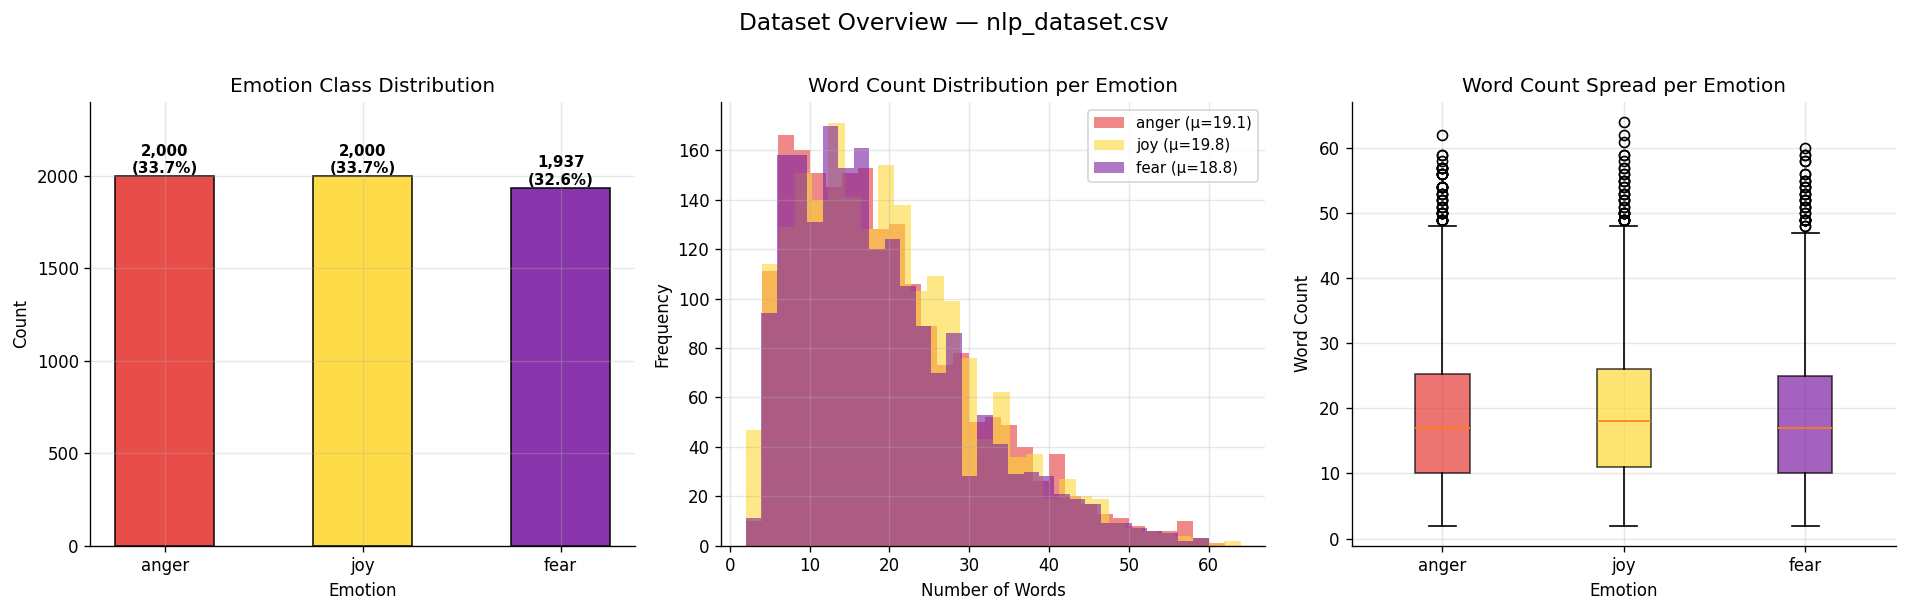

Average comment length: 19.3 words  (min=2, max=64)


In [4]:
df['word_count'] = df['Comment'].str.split().str.len()
df['char_count'] = df['Comment'].str.len()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Class distribution
counts  = df['Emotion'].value_counts()
colors  = [EMOTION_COLORS[e] for e in counts.index]
bars    = axes[0].bar(counts.index, counts.values, color=colors,
                      edgecolor='black', alpha=0.9, width=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Emotion Class Distribution', fontsize=12)
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, 2400)

# 2. Word count distribution per class
for emotion, color in EMOTION_COLORS.items():
    subset = df[df['Emotion'] == emotion]['word_count']
    axes[1].hist(subset, bins=30, alpha=0.6, color=color,
                 label=f'{emotion} (μ={subset.mean():.1f})', edgecolor='none')
axes[1].set_title('Word Count Distribution per Emotion', fontsize=12)
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=9)

# 3. Boxplot of word count per class
data_by_class = [df[df['Emotion'] == e]['word_count'].values
                 for e in ['anger', 'joy', 'fear']]
bp = axes[2].boxplot(data_by_class, patch_artist=True,
                     labels=['anger', 'joy', 'fear'])
for patch, color in zip(bp['boxes'], EMOTION_COLORS.values()):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[2].set_title('Word Count Spread per Emotion', fontsize=12)
axes[2].set_xlabel('Emotion')
axes[2].set_ylabel('Word Count')

plt.suptitle('Dataset Overview — nlp_dataset.csv', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f"Average comment length: {df['word_count'].mean():.1f} words  "
      f"(min={df['word_count'].min()}, max={df['word_count'].max()})")

In [5]:
STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text: str) -> str:
    """
    Full text cleaning pipeline:
      1. Lowercase
      2. Remove URLs, @mentions, #hashtags
      3. Remove punctuation and digits
      4. Tokenize
      5. Remove stopwords and single-char tokens
      6. Lemmatize
    Returns a single cleaned string ready for vectorisation.
    """
    text = str(text).lower()                            # 1. lowercase
    text = re.sub(r'http\S+|www\.\S+', '', text)        # 2a. URLs
    text = re.sub(r'@\w+|#\w+', '', text)               # 2b. mentions & hashtags
    text = re.sub(r'[^a-z\s]', '', text)                # 3. keep only letters
    tokens = word_tokenize(text)                        # 4. tokenize
    tokens = [t for t in tokens                         # 5. stopwords
              if t not in STOP_WORDS and len(t) > 1]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]  # 6. lemmatize
    return ' '.join(tokens)

print("Applying preprocessing...")
df['clean_text'] = df['Comment'].apply(preprocess_text)
print(f"Done — {len(df):,} samples processed.")

# Vocabulary reduction
vocab_before = set(' '.join(df['Comment'].str.lower()).split())
vocab_after  = set(' '.join(df['clean_text']).split())
print(f"\nVocabulary before : {len(vocab_before):,} tokens")
print(f"Vocabulary after  : {len(vocab_after):,} tokens")
print(f"Reduction         : {(1 - len(vocab_after)/len(vocab_before))*100:.1f}%")

# Before / after examples
print("\n── Before vs After (5 samples) ──")
pd.set_option('display.max_colwidth', 90)
df[['Comment','clean_text','Emotion']].head(5)

Applying preprocessing...
Done — 5,937 samples processed.

Vocabulary before : 8,979 tokens
Vocabulary after  : 7,977 tokens
Reduction         : 11.2%

── Before vs After (5 samples) ──


,Comment,clean_text,Emotion
0,i seriously hate one subject to death but now i feel reluctant to drop it,seriously hate one subject death feel reluctant drop,fear
1,im so full of life i feel appalled,im full life feel appalled,anger
2,i sit here to write i start to dig out my feelings and i think that i am afraid to acc...,sit write start dig feeling think afraid accept possibility might make,fear
3,ive been really angry with r and i feel like an idiot for trusting him in the first place,ive really angry feel like idiot trusting first place,joy
4,i feel suspicious if there is no one outside like the rapture has happened or something,feel suspicious one outside like rapture happened something,fear


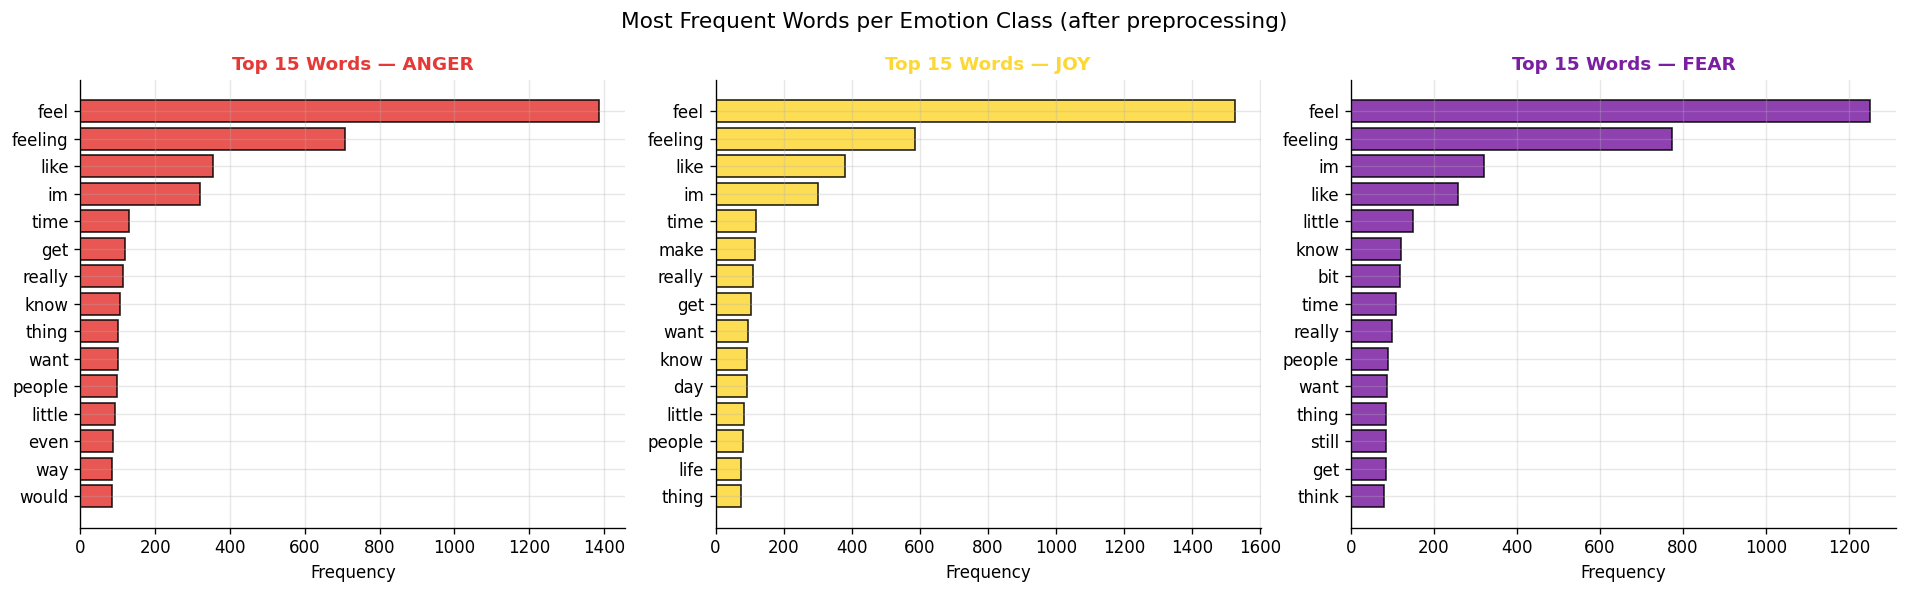

In [6]:
# ── Top Words per Emotion (after cleaning) ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (emotion, color) in zip(axes, EMOTION_COLORS.items()):
    tokens  = ' '.join(df[df['Emotion'] == emotion]['clean_text']).split()
    common  = Counter(tokens).most_common(15)
    words, freqs = zip(*common)
    ax.barh(words[::-1], freqs[::-1], color=color, edgecolor='black', alpha=0.85)
    ax.set_title(f'Top 15 Words — {emotion.upper()}', fontsize=11,
                 fontweight='bold', color=color)
    ax.set_xlabel('Frequency')

plt.suptitle('Most Frequent Words per Emotion Class (after preprocessing)', fontsize=13)
plt.tight_layout()
plt.show()

In [7]:
# ── Train / Validation / Test Split (70 / 10 / 20) ──
X = df['clean_text']
y = df['Emotion']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"Training samples : {len(X_train):,}  ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test samples     : {len(X_test):,}  ({len(X_test)/len(X)*100:.0f}%)")

print("\nClass distribution in train set:")
print(y_train.value_counts())
print("\nClass distribution in test set:")
print(y_test.value_counts())

Training samples : 4,749  (80%)
Test samples     : 1,188  (20%)

Class distribution in train set:
Emotion
anger    1600
joy      1600
fear     1549
Name: count, dtype: int64

Class distribution in test set:
Emotion
joy      400
anger    400
fear     388
Name: count, dtype: int64


In [8]:
# ── TF-IDF Vectorizer ──
tfidf = TfidfVectorizer(
    ngram_range  = (1, 2),   # unigrams AND bigrams
    max_features = 20000,    # keep top 20k features
    sublinear_tf = True,     # log(1+tf) to dampen very frequent terms
    min_df       = 2,        # ignore terms in < 2 documents (reduce noise)
    max_df       = 0.95,     # ignore terms in > 95% of documents (too common)
    strip_accents = 'unicode'
)

# IMPORTANT: fit ONLY on training data to prevent data leakage
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"TF-IDF matrix — train : {X_train_tfidf.shape}")
print(f"TF-IDF matrix — test  : {X_test_tfidf.shape}")
print(f"Actual vocabulary     : {len(tfidf.vocabulary_):,} features")
sparsity = 1.0 - X_train_tfidf.nnz / np.prod(X_train_tfidf.shape)
print(f"Matrix sparsity       : {sparsity*100:.2f}%  (typical for text data)")

TF-IDF matrix — train : (4749, 5601)
TF-IDF matrix — test  : (1188, 5601)
Actual vocabulary     : 5,601 features
Matrix sparsity       : 99.81%  (typical for text data)


Top 15 TF-IDF features per emotion class:
------------------------------------------------------------
  ANGER   : feel, feeling, like, im, feel like, im feeling, get, really, cold, time, angry, people, resentful, know, insulted
  JOY     : feel, feeling, like, im, feel like, im feeling, really, time, make, good, day, get, something, want, life
  FEAR    : feel, feeling, im, like, little, bit, feel like, im feeling, terrified, strange, know, anxious, weird, nervous, insecure


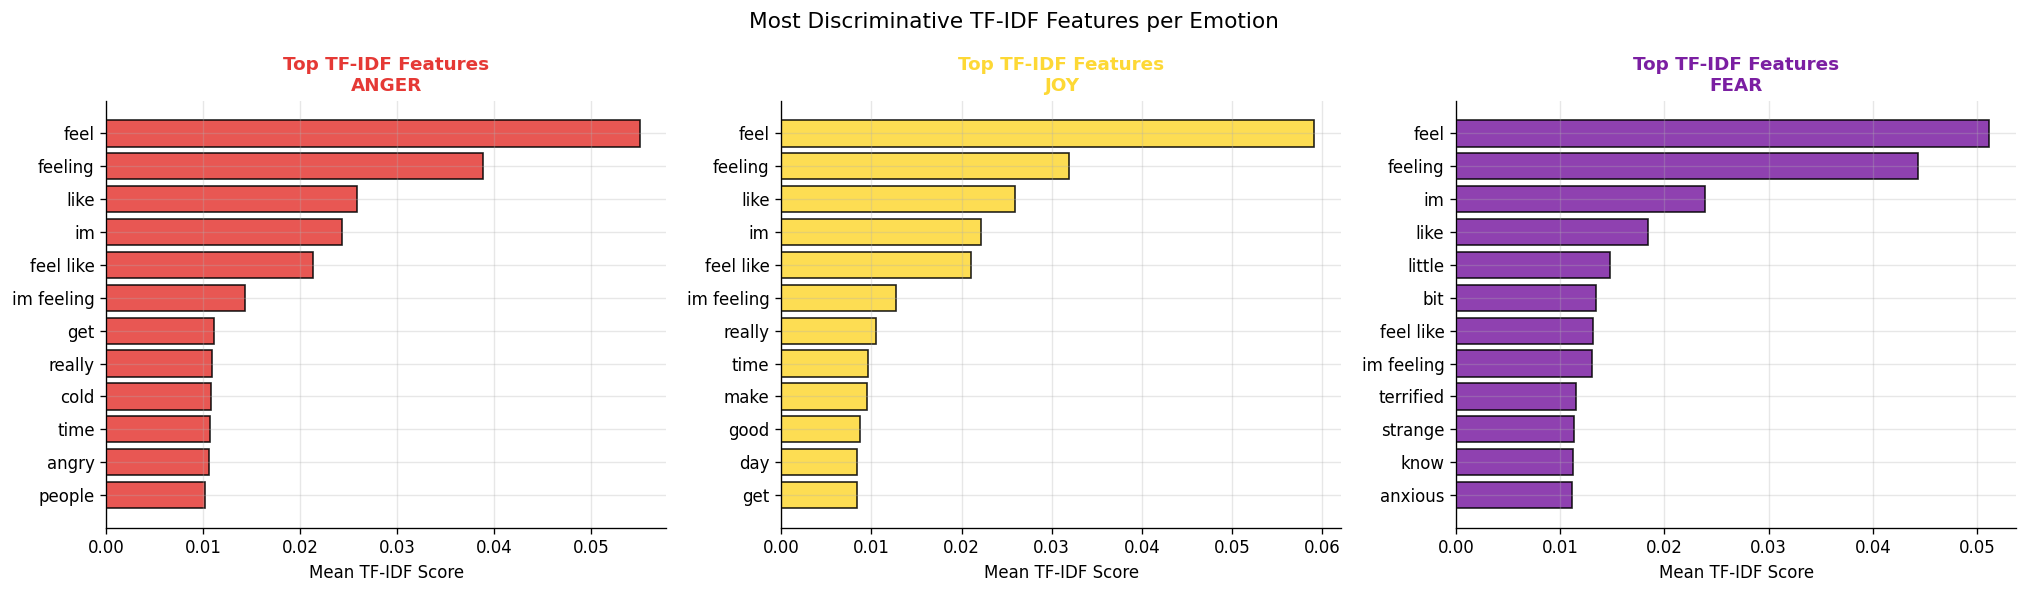

In [9]:
# ── Top TF-IDF discriminative features per emotion ──
feature_names = np.array(tfidf.get_feature_names_out())

print("Top 15 TF-IDF features per emotion class:")
print("-" * 60)
for emotion in ['anger', 'joy', 'fear']:
    mask       = (y_train == emotion).values
    mean_score = np.asarray(X_train_tfidf[mask].mean(axis=0)).flatten()
    top15      = feature_names[np.argsort(mean_score)[-15:][::-1]]
    print(f"  {emotion.upper():<8}: {', '.join(top15)}")

# Visualise top features
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (emotion, color) in zip(axes, EMOTION_COLORS.items()):
    mask       = (y_train == emotion).values
    mean_score = np.asarray(X_train_tfidf[mask].mean(axis=0)).flatten()
    top_idx    = np.argsort(mean_score)[-12:][::-1]
    top_words  = feature_names[top_idx]
    top_scores = mean_score[top_idx]
    ax.barh(top_words[::-1], top_scores[::-1], color=color, edgecolor='black', alpha=0.85)
    ax.set_title(f'Top TF-IDF Features\n{emotion.upper()}', fontsize=11,
                 fontweight='bold', color=color)
    ax.set_xlabel('Mean TF-IDF Score')

plt.suptitle('Most Discriminative TF-IDF Features per Emotion', fontsize=13)
plt.tight_layout()
plt.show()

In [10]:
# ── Train Naive Bayes ──
nb = MultinomialNB(alpha=0.1)   # lighter smoothing than default 1.0
nb.fit(X_train_tfidf, y_train)

y_pred_nb   = nb.predict(X_test_tfidf)
acc_nb      = accuracy_score(y_test, y_pred_nb)
f1_nb_w     = f1_score(y_test, y_pred_nb, average='weighted')
f1_nb_mac   = f1_score(y_test, y_pred_nb, average='macro')

print("━" * 52)
print("  NAIVE BAYES — Test Set Results")
print("━" * 52)
print(f"  Accuracy        : {acc_nb:.4f}  ({acc_nb*100:.2f}%)")
print(f"  F1 (weighted)   : {f1_nb_w:.4f}")
print(f"  F1 (macro)      : {f1_nb_mac:.4f}")
print()
print(classification_report(y_test, y_pred_nb,
      target_names=['anger', 'fear', 'joy']))

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  NAIVE BAYES — Test Set Results
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Accuracy        : 0.8923  (89.23%)
  F1 (weighted)   : 0.8923
  F1 (macro)      : 0.8923

              precision    recall  f1-score   support

       anger       0.90      0.88      0.89       400
        fear       0.87      0.91      0.89       388
         joy       0.91      0.89      0.90       400

    accuracy                           0.89      1188
   macro avg       0.89      0.89      0.89      1188
weighted avg       0.89      0.89      0.89      1188



In [11]:
# ── Train Linear SVM ──
svm = LinearSVC(C=1.0, max_iter=3000, random_state=RANDOM_STATE)
svm.fit(X_train_tfidf, y_train)

y_pred_svm  = svm.predict(X_test_tfidf)
acc_svm     = accuracy_score(y_test, y_pred_svm)
f1_svm_w    = f1_score(y_test, y_pred_svm, average='weighted')
f1_svm_mac  = f1_score(y_test, y_pred_svm, average='macro')

print("━" * 52)
print("  LINEAR SVM — Test Set Results")
print("━" * 52)
print(f"  Accuracy        : {acc_svm:.4f}  ({acc_svm*100:.2f}%)")
print(f"  F1 (weighted)   : {f1_svm_w:.4f}")
print(f"  F1 (macro)      : {f1_svm_mac:.4f}")
print()
print(classification_report(y_test, y_pred_svm,
      target_names=['anger', 'fear', 'joy']))

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  LINEAR SVM — Test Set Results
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Accuracy        : 0.9386  (93.86%)
  F1 (weighted)   : 0.9385
  F1 (macro)      : 0.9385

              precision    recall  f1-score   support

       anger       0.93      0.94      0.93       400
        fear       0.94      0.92      0.93       388
         joy       0.95      0.95      0.95       400

    accuracy                           0.94      1188
   macro avg       0.94      0.94      0.94      1188
weighted avg       0.94      0.94      0.94      1188



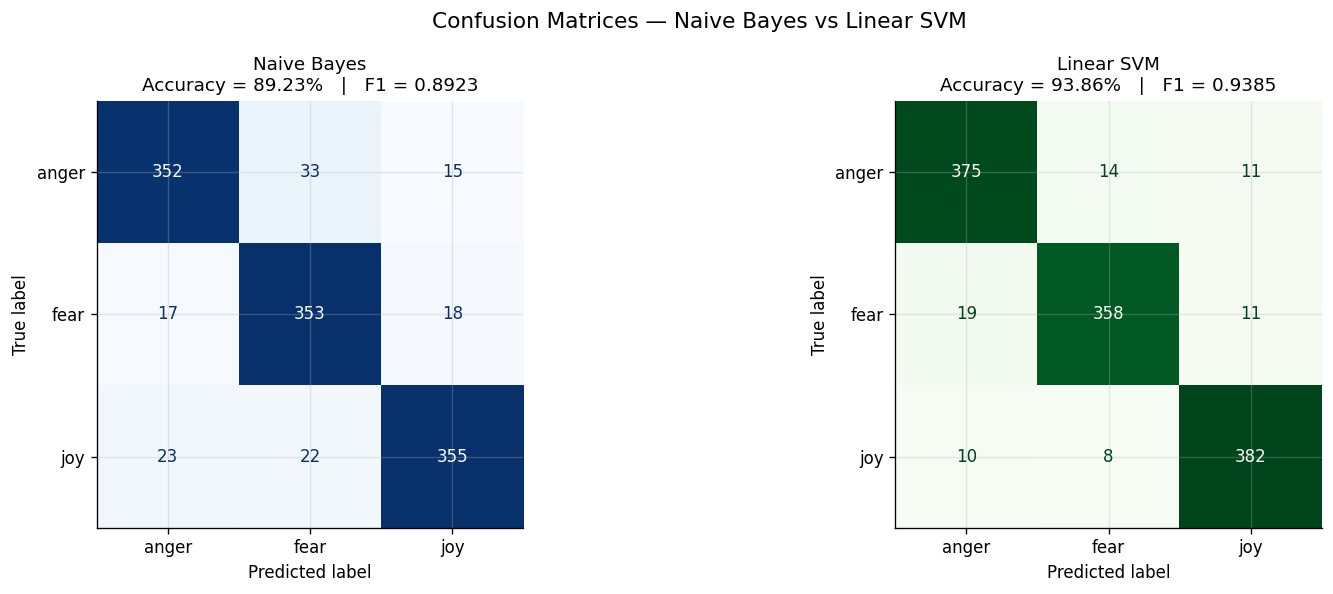

In [12]:
# ── Confusion Matrices (side-by-side) ──
classes = ['anger', 'fear', 'joy']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (y_pred, title, cmap) in zip(
    axes,
    [(y_pred_nb,  'Naive Bayes',  'Blues'),
     (y_pred_svm, 'Linear SVM',   'Greens')]
):
    cm   = confusion_matrix(y_test, y_pred, labels=classes)
    disp = ConfusionMatrixDisplay(cm, display_labels=classes)
    disp.plot(ax=ax, cmap=cmap, colorbar=False, xticks_rotation=0)
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='weighted')
    ax.set_title(f'{title}\nAccuracy = {acc*100:.2f}%   |   F1 = {f1:.4f}',
                 fontsize=11)

plt.suptitle('Confusion Matrices — Naive Bayes vs Linear SVM', fontsize=13)
plt.tight_layout()
plt.show()

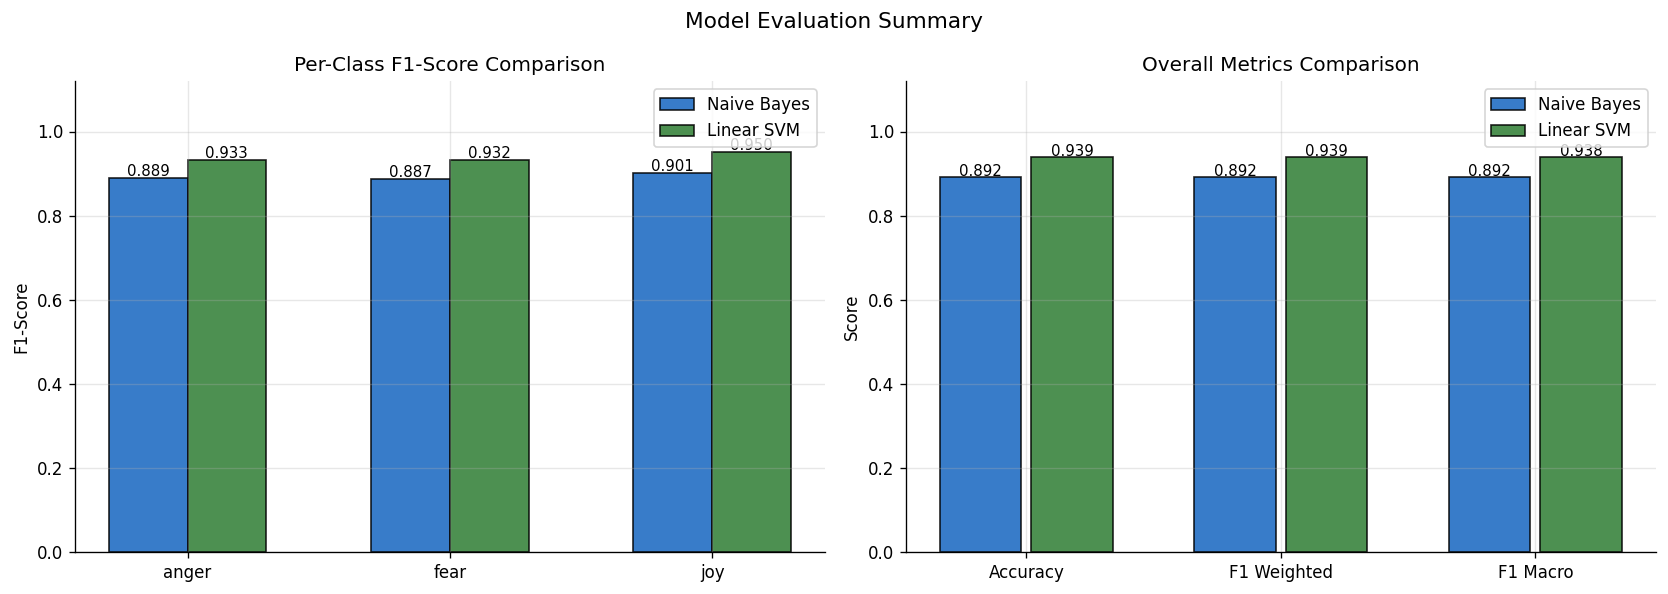

In [13]:
# ── Per-class F1 grouped bar chart ──
from sklearn.metrics import classification_report

rep_nb  = classification_report(y_test, y_pred_nb,  output_dict=True)
rep_svm = classification_report(y_test, y_pred_svm, output_dict=True)

f1_nb_per  = [rep_nb[c]['f1-score']  for c in classes]
f1_svm_per = [rep_svm[c]['f1-score'] for c in classes]

x     = np.arange(len(classes))
width = 0.30
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Per-class F1
bars1 = axes[0].bar(x - width/2, f1_nb_per,  width,
                    label='Naive Bayes', color='#1565C0', alpha=0.85, edgecolor='black')
bars2 = axes[0].bar(x + width/2, f1_svm_per, width,
                    label='Linear SVM',  color='#2E7D32', alpha=0.85, edgecolor='black')
for bar in list(bars1) + list(bars2):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', fontsize=9)
axes[0].set_xticks(x)
axes[0].set_xticklabels(classes)
axes[0].set_ylim(0, 1.12)
axes[0].set_ylabel('F1-Score')
axes[0].set_title('Per-Class F1-Score Comparison', fontsize=12)
axes[0].legend(fontsize=10)

# Overall metric comparison
metric_labels = ['Accuracy', 'F1 Weighted', 'F1 Macro']
nb_vals  = [acc_nb,    f1_nb_w,   f1_nb_mac]
svm_vals = [acc_svm,   f1_svm_w,  f1_svm_mac]
x2 = np.arange(len(metric_labels))
axes[1].bar(x2 - 0.18, nb_vals,  0.32,
            label='Naive Bayes', color='#1565C0', alpha=0.85, edgecolor='black')
axes[1].bar(x2 + 0.18, svm_vals, 0.32,
            label='Linear SVM',  color='#2E7D32', alpha=0.85, edgecolor='black')
for i, (nb_v, svm_v) in enumerate(zip(nb_vals, svm_vals)):
    axes[1].text(i - 0.18, nb_v  + 0.003, f'{nb_v:.3f}',  ha='center', fontsize=9)
    axes[1].text(i + 0.18, svm_v + 0.003, f'{svm_v:.3f}', ha='center', fontsize=9)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(metric_labels)
axes[1].set_ylim(0, 1.12)
axes[1].set_ylabel('Score')
axes[1].set_title('Overall Metrics Comparison', fontsize=12)
axes[1].legend(fontsize=10)

plt.suptitle('Model Evaluation Summary', fontsize=13)
plt.tight_layout()
plt.show()

Running 5-fold cross-validation...

Naive Bayes  CV Accuracy: 0.8858  ± 0.0073
Linear SVM   CV Accuracy: 0.9488  ± 0.0057


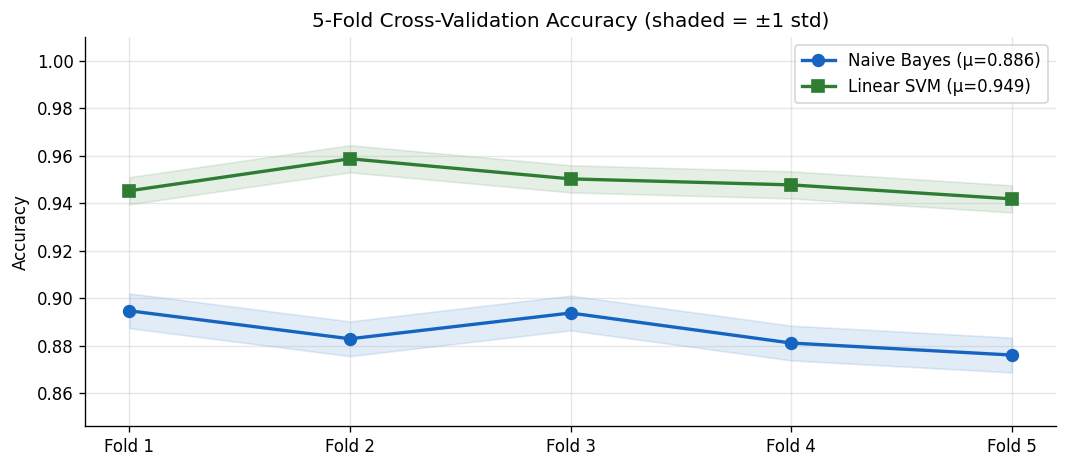

In [14]:
# ── 5-Fold Stratified Cross-Validation ──
print("Running 5-fold cross-validation...")
X_full_tfidf = tfidf.transform(X)   # re-use fitted vectoriser on full dataset
cv           = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_nb  = cross_val_score(MultinomialNB(alpha=0.1), X_full_tfidf, y,
                          cv=cv, scoring='accuracy')
cv_svm = cross_val_score(LinearSVC(C=1.0, max_iter=3000, random_state=RANDOM_STATE),
                          X_full_tfidf, y, cv=cv, scoring='accuracy')

print(f"\nNaive Bayes  CV Accuracy: {cv_nb.mean():.4f}  ± {cv_nb.std():.4f}")
print(f"Linear SVM   CV Accuracy: {cv_svm.mean():.4f}  ± {cv_svm.std():.4f}")

# Plot CV fold-by-fold
fig, ax = plt.subplots(figsize=(9, 4))
folds = [f'Fold {i+1}' for i in range(5)]
x     = np.arange(5)
ax.plot(x, cv_nb,  'o-', color='#1565C0', lw=2, ms=7, label=f'Naive Bayes (μ={cv_nb.mean():.3f})')
ax.plot(x, cv_svm, 's-', color='#2E7D32', lw=2, ms=7, label=f'Linear SVM (μ={cv_svm.mean():.3f})')
ax.fill_between(x, cv_nb  - cv_nb.std(),  cv_nb  + cv_nb.std(),  alpha=0.12, color='#1565C0')
ax.fill_between(x, cv_svm - cv_svm.std(), cv_svm + cv_svm.std(), alpha=0.12, color='#2E7D32')
ax.set_xticks(x)
ax.set_xticklabels(folds)
ax.set_ylabel('Accuracy')
ax.set_title('5-Fold Cross-Validation Accuracy (shaded = ±1 std)', fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(max(0, min(cv_nb.min(), cv_svm.min()) - 0.03), 1.01)
plt.tight_layout()
plt.show()

In [15]:
# ── Final Summary Table ──
summary = pd.DataFrame({
    'Model'         : ['Naive Bayes', 'Linear SVM'],
    'Accuracy'      : [round(acc_nb,    4), round(acc_svm,    4)],
    'F1 (weighted)' : [round(f1_nb_w,   4), round(f1_svm_w,   4)],
    'F1 (macro)'    : [round(f1_nb_mac, 4), round(f1_svm_mac, 4)],
    'CV Accuracy'   : [round(cv_nb.mean(),  4), round(cv_svm.mean(),  4)],
    'CV Std'        : [round(cv_nb.std(),   4), round(cv_svm.std(),   4)]
})

print("=" * 68)
print("   FINAL MODEL COMPARISON — nlp_dataset.csv")
print("=" * 68)
print(summary.to_string(index=False))
print("=" * 68)
winner = 'Linear SVM' if acc_svm >= acc_nb else 'Naive Bayes'
print(f"\n  ✓ Best performing model: {winner}")

   FINAL MODEL COMPARISON — nlp_dataset.csv
      Model  Accuracy  F1 (weighted)  F1 (macro)  CV Accuracy  CV Std
Naive Bayes    0.8923         0.8923      0.8923       0.8858  0.0073
 Linear SVM    0.9386         0.9385      0.9385       0.9488  0.0057

  ✓ Best performing model: Linear SVM


In [16]:
# ── Live Prediction Demo ──
test_sentences = [
    "I am so furious about what happened today",
    "This is the happiest moment of my entire life",
    "I am terrified and trembling I don't know what to do",
    "I feel overjoyed and grateful for everything around me",
    "The thought of losing someone fills me with dread",
    "How dare they treat people this way it makes me so mad"
]

cleaned    = [preprocess_text(s) for s in test_sentences]
vectorised = tfidf.transform(cleaned)

preds_nb  = nb.predict(vectorised)
preds_svm = svm.predict(vectorised)

print(f"{'Text':<53} {'NB':^10} {'SVM':^10} {'Match':^6}")
print("-" * 82)
for text, p_nb, p_svm in zip(test_sentences, preds_nb, preds_svm):
    match = '✓' if p_nb == p_svm else '✗'
    print(f"{text[:52]:<53} {p_nb:^10} {p_svm:^10} {match:^6}")

Text                                                      NB        SVM     Match 
----------------------------------------------------------------------------------
I am so furious about what happened today               anger      anger      ✓   
This is the happiest moment of my entire life           anger      anger      ✓   
I am terrified and trembling I don't know what to do     fear       fear      ✓   
I feel overjoyed and grateful for everything around     anger       joy       ✗   
The thought of losing someone fills me with dread        fear       fear      ✓   
How dare they treat people this way it makes me so m    anger      anger      ✓   
